In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tools.tools import *
from tools.bag_to_df import bag_topic_to_dataframe
import pandas as pd
from scipy.spatial.transform import Rotation as R
from tools.signal_properties import compare_signals


%load_ext autoreload
%autoreload 2

REAL_BAG_PATH = "/root/stonefish_ros2_ws/sintef_dataset/2024-08-22_14-29-05_data.bag"
SIM_BAG_PATH = "/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_11_17-10_40_53"

# Test:
# SIM_BAG_PATH = "/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_11_14-13_53_59" # I (0.0 0.0 0.0)
# SIM_BAG_PATH = "/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_11_14-14_47_21" # I (1.0 1.0 1.0)


# Test etter oppdatert kode
# SIM_BAG_PATH = "/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_11_14-17_06_09"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [121]:
print_bag_topics(REAL_BAG_PATH)

Topics and message types:
/bluerov2/alive                                std_msgs/msg/Float32
/bluerov2/armed                                std_msgs/msg/Float32
/bluerov2/battery                              messages/msg/BatteryStatus
/bluerov2/modes                                joystick/msg/ModeManager2
/commanded_thrust                              rospy_tutorials/msg/Floats
/controller/x                                  messages/msg/MRACOupdate
/controller/y                                  messages/msg/MRACOupdate
/controller/yaw                                messages/msg/PIDState
/controller/z                                  messages/msg/PIDState
/gui/netFollowing_manager                      messages/msg/NetFollowingManager
/guidance                                      messages/msg/GuidanceManager
/joystick                                      joystick/msg/Joystick
/joystick/dvl_reset_position                   messages/msg/BoolStamped
/joystick/init                        

# Read data

In [122]:
from tools.data import Nucleus

xyz_post = np.array([23.6688, 4.5, 0])
rpy_post = np.array([0, 0, -2.1])
ins_data = Nucleus(REAL_BAG_PATH, xyz_post, rpy_post)

nucleus_alitmeter = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/altimeter")
nucleus_bottomtrack = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/bottomtrack")
nucleus_magnetometer = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/magnetometer")
nucleus_watertrack = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/watertrack")


imu_sensor = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/imu")
nucleus_imu = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/imu")

# A50
dvl_a50_position = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/dvl_position")
dvl_a50_velocity = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/dvl_velocity")

# SIM
sim_dvl = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/dvl")
sim_a50 = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/dvl_a50")
sim_gt = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth")
sim_gt_dvl = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth_dvl")
sim_ins = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ins")
sim_imu = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/imu")
print("")

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')
/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


# Normalize time

Use the first element of ground truth running at 100 Hz as the starting point of time. Topics spawn after some time

In [123]:
imu = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/imu")
t0_real = imu["t"][0]
t0_real = ins_data.df_ins["t"][0]

# Get t0 of simulation
t0_sim = sim_gt["t"].iloc[0] - 0.4
t0_sim = sim_gt["t"].iloc[0]


def set_t0(df: pd.DataFrame, t_0):
    df["t"] -= t_0

# Subtract t0
set_t0(sim_gt, t0_sim)
set_t0(sim_gt_dvl, t0_sim)
set_t0(sim_a50, t0_sim)
set_t0(sim_dvl, t0_sim)
set_t0(sim_ins, t0_sim)
set_t0(sim_imu, t0_sim)

ins_data.set_t0(t0_real)
set_t0(nucleus_alitmeter, t0_real)
set_t0(nucleus_bottomtrack, t0_real)
set_t0(nucleus_magnetometer, t0_real)
set_t0(nucleus_watertrack, t0_real)
set_t0(dvl_a50_position, t0_real)
set_t0(dvl_a50_velocity, t0_real)
set_t0(imu_sensor, t0_real)
set_t0(nucleus_imu, t0_real)


# Sway Velocity

Ground truth - simulated dvl:
{'rmse': 0.011321680760031018, 'corr': 0.9419988729025891, 'mean1': -0.09554204971799296, 'mean2': -0.09602241495621774, 'mean_error': 0.0004803652382247783, 'var_signal1': 0.0011285038243231266, 'var_signal2': 0.0009401770160332121, 'var_difference': 0.00018832680828991444, 'var_ratio_s1_over_s2': 1.2003099470400813, 'cv_signal1': 0.3516065552786115, 'cv_signal2': 0.3193244631974101, 'kurtosis_signal1': 1.5273752231767652, 'kurtosis_signal2': 0.359495851686654, 'kurtosis_difference': 1.1678793714901112}

Ground truth - Real:
{'rmse': 0.02989061063214896, 'corr': 0.443618594446891, 'mean1': -0.0967698732153657, 'mean2': -0.09933174387342655, 'mean_error': 0.0025618706580608453, 'var_signal1': 0.0010658674650362702, 'var_signal2': 0.0004044251974366434, 'var_difference': 0.0006614422675996269, 'var_ratio_s1_over_s2': 2.635512010112197, 'cv_signal1': 0.33737386061827707, 'cv_signal2': 0.20245618226393278, 'kurtosis_signal1': 1.5373039045065378, 'kurtosis_sig

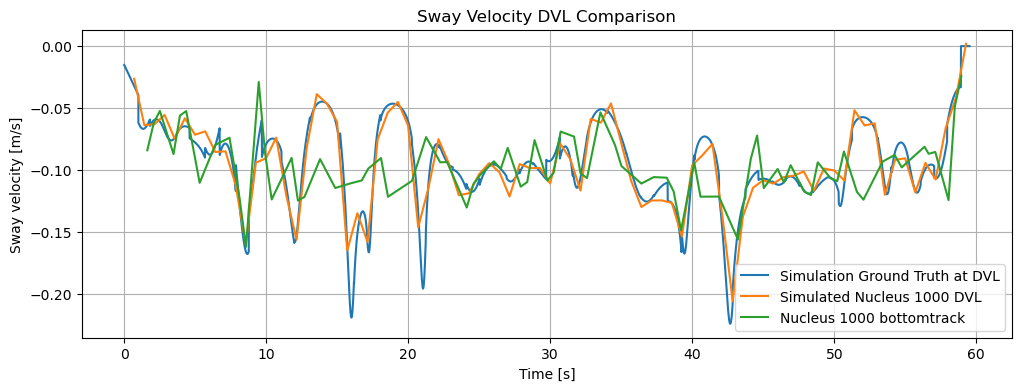

In [124]:
# Remove outlier value of dvl bottomtrack
nucleus_bottomtrack = nucleus_bottomtrack[nucleus_bottomtrack["dvl_velocity_xyz.x"] > 0]
nucleus_vel_xyz = np.array([nucleus_bottomtrack])

t_gt, data_gt = sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.y"].values
t_sim_dvl, data_sim_dvl = sim_dvl["t"].values, sim_dvl["velocity.y"].values
t_bt, data_bt = nucleus_bottomtrack["t"].values, -nucleus_bottomtrack["dvl_velocity_xyz.x"].values

# Remove lag from nucleus bottomtrack
lag_sec = get_signal_lag(t_bt, data_bt, t_gt, data_gt)
t_bt += lag_sec

plt.figure(figsize=(12, 4))

# --- GROUND THRUTH ---
plt.plot(t_gt, data_gt, label="Simulation Ground Truth at DVL")

# --- SIMULATED NUCLEUS ---
plt.plot(t_sim_dvl, data_sim_dvl, label="Simulated Nucleus 1000 DVL")

# --- NUCLEUS BOTTOMTRACK ---
plt.plot(t_bt, data_bt, label="Nucleus 1000 bottomtrack")

plt.title("Sway Velocity DVL Comparison")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")

plt.legend()
plt.grid()

comp_simulated = compare_signals(t_gt, data_gt,
                        t_sim_dvl, data_sim_dvl)

comp_real      = compare_signals(t_gt, data_gt ,
                        t_bt, data_bt)

comp_real_vs_sim = compare_signals(t_sim_dvl, data_sim_dvl,
                        t_bt, data_bt)
print("Ground truth - simulated dvl:")
print(comp_simulated)
print("\nGround truth - Real:")
print(comp_real)
print("\nSimulated - Real:")
print(comp_real_vs_sim)

Ground truth - simulated dvl:
{'rmse': 0.008136562875404166, 'corr': 0.8847928768963426, 'mean1': 0.004287254900687902, 'mean2': 0.004760678480699936, 'mean_error': -0.00047342358001203406, 'var_signal1': 0.0002803906128834274, 'var_signal2': 0.00029198432480382285, 'var_difference': -1.1593711920395474e-05, 'var_ratio_s1_over_s2': 0.9602933755838262, 'cv_signal1': 3.905731906095903, 'cv_signal2': 3.5893095685872405, 'kurtosis_signal1': 2.9791151503649314, 'kurtosis_signal2': 2.4085647074601155, 'kurtosis_difference': 0.5705504429048158}

Ground truth - Real:
{'rmse': 0.011897596839613297, 'corr': 0.781054404048228, 'mean1': 0.004315200036680152, 'mean2': 0.006493696619306049, 'mean_error': -0.0021784965826258974, 'var_signal1': 0.0002833493955687987, 'var_signal2': 0.00033454235362851694, 'var_difference': -5.1192958059718236e-05, 'var_ratio_s1_over_s2': 0.8469761526321896, 'cv_signal1': 3.900858639286009, 'cv_signal2': 2.8166543759551126, 'kurtosis_signal1': 2.961425410085492, 'kurto

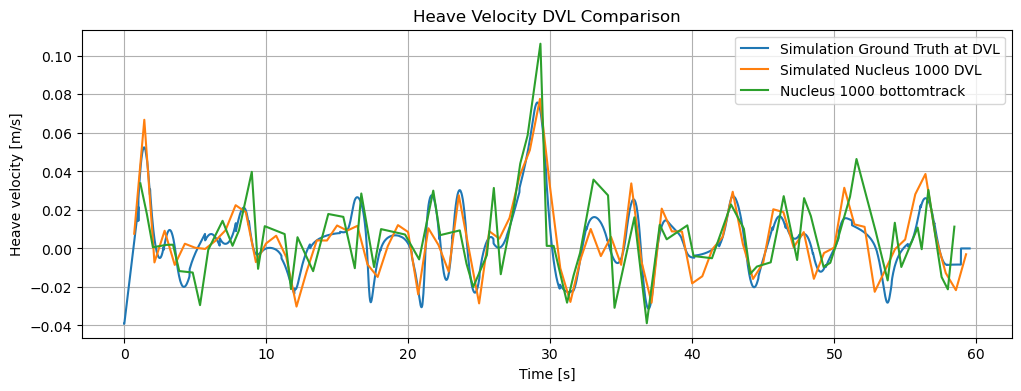

In [125]:
t_gt, data_gt = sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.z"].values
t_sim_dvl, data_sim_dvl = sim_dvl["t"].values, sim_dvl["velocity.x"].values
t_bt, data_bt = nucleus_bottomtrack["t"].values, -nucleus_bottomtrack["dvl_velocity_xyz.y"].values

lag_sec = get_signal_lag(t_bt, data_bt, t_gt, data_gt)
t_bt += lag_sec

plt.figure(figsize=(12, 4))

# --- GROUND THRUTH ---
plt.plot(t_gt, data_gt, label="Simulation Ground Truth at DVL")

# --- SIMULATED NUCLEUS ---
plt.plot(t_sim_dvl, data_sim_dvl, label="Simulated Nucleus 1000 DVL")

# --- NUCLEUS BOTTOMTRACK ---
plt.plot(t_bt, data_bt, label="Nucleus 1000 bottomtrack")

plt.title("Heave Velocity DVL Comparison")
plt.xlabel("Time [s]")
plt.ylabel("Heave velocity [m/s]")

plt.legend()
plt.grid()

comp_simulated = compare_signals(t_gt, data_gt,
                        t_sim_dvl, data_sim_dvl)

comp_real      = compare_signals(t_gt, data_gt ,
                        t_bt, data_bt)

comp_real_vs_sim = compare_signals(t_sim_dvl, data_sim_dvl,
                        t_bt, data_bt)
print("Ground truth - simulated dvl:")
print(comp_simulated)
print("\nGround truth - Real:")
print(comp_real)
print("\nSimulated - Real:")
print(comp_real_vs_sim)

# DVL A50 velovity comparison

Simulated - Real:
{'rmse': 0.032609581886353274, 'corr': 0.49851376036722794, 'mean1': -0.0944603699643078, 'mean2': -0.09386322799172046, 'mean_error': -0.0005971419725873479, 'var_signal1': 0.001315164105608919, 'var_signal2': 0.0007173371796415877, 'var_difference': 0.0005978269259673312, 'var_ratio_s1_over_s2': 1.8333973798291496, 'cv_signal1': 0.38391964154578295, 'cv_signal2': 0.2853423178941992, 'kurtosis_signal1': 1.0428590988301982, 'kurtosis_signal2': 1.5647693207142996, 'kurtosis_difference': -0.5219102218841014}


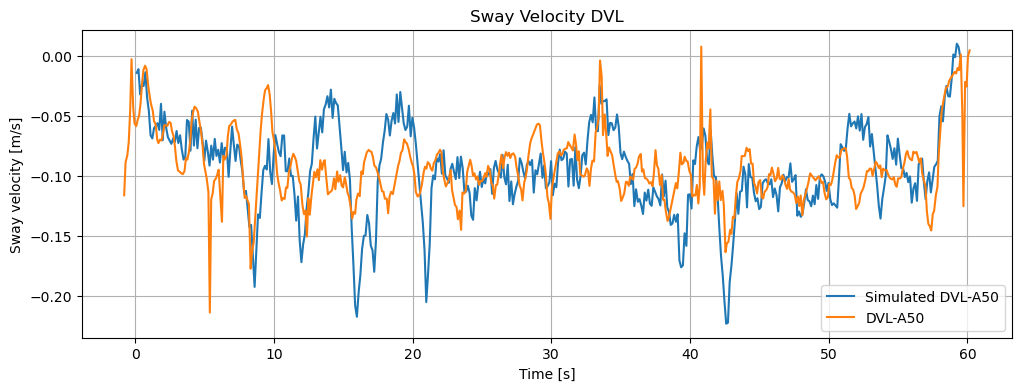

In [126]:
# Remove outlier value of dvl bottomtrack

t1, data1 = sim_a50["t"].values, sim_a50["velocity.y"].values
t2, data2 = dvl_a50_velocity["t"].values, -dvl_a50_velocity["velocity.x"].values

lag_sec = get_signal_lag(t1, data1, t2, data2)
t2 -= lag_sec

plt.figure(figsize=(12, 4))

# --- SIMULATED A50 ---
plt.plot(t1, data1, label="Simulated DVL-A50")

# --- REAL A50 ---
plt.plot(t2, data2, label="DVL-A50")


plt.title("Sway Velocity DVL")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")

plt.legend()
plt.grid()

comp_real_vs_sim = compare_signals(t1, data1,
                        t2, data2)
print("Simulated - Real:")
print(comp_real_vs_sim)

Diskusjon: Erroren vil forplante seg gjennom rekonstrueringen av signalet

# Position comparison

{'rmse': 0.007782884468399884, 'corr': 0.9958298328738593, 'mean1': 24.24415685513166, 'mean2': 24.24453306676218, 'mean_error': -0.00037621163052200044, 'var_signal1': 0.007049573856579974, 'var_signal2': 0.00721825660190473, 'var_difference': -0.00016868274532475663, 'var_ratio_s1_over_s2': 0.9766310960349837, 'cv_signal1': 0.0034631742788561997, 'cv_signal2': 0.0035043085160011227, 'kurtosis_signal1': -0.8396661537275385, 'kurtosis_signal2': -0.8572704399057942, 'kurtosis_difference': 0.017604286178255713}
{'rmse': 0.012120280996921785, 'corr': 0.9999753277226052, 'mean1': -0.08363143263897461, 'mean2': -0.08132294674566333, 'mean_error': -0.002308485893311338, 'var_signal1': 2.8719197459554935, 'var_signal2': 2.871627792597742, 'var_difference': 0.0002919533577516731, 'var_ratio_s1_over_s2': 1.000101668244925, 'cv_signal1': 20.263600437312498, 'cv_signal2': 20.83775689538072, 'kurtosis_signal1': -1.2190462439471708, 'kurtosis_signal2': -1.2173647512335655, 'kurtosis_difference': -0

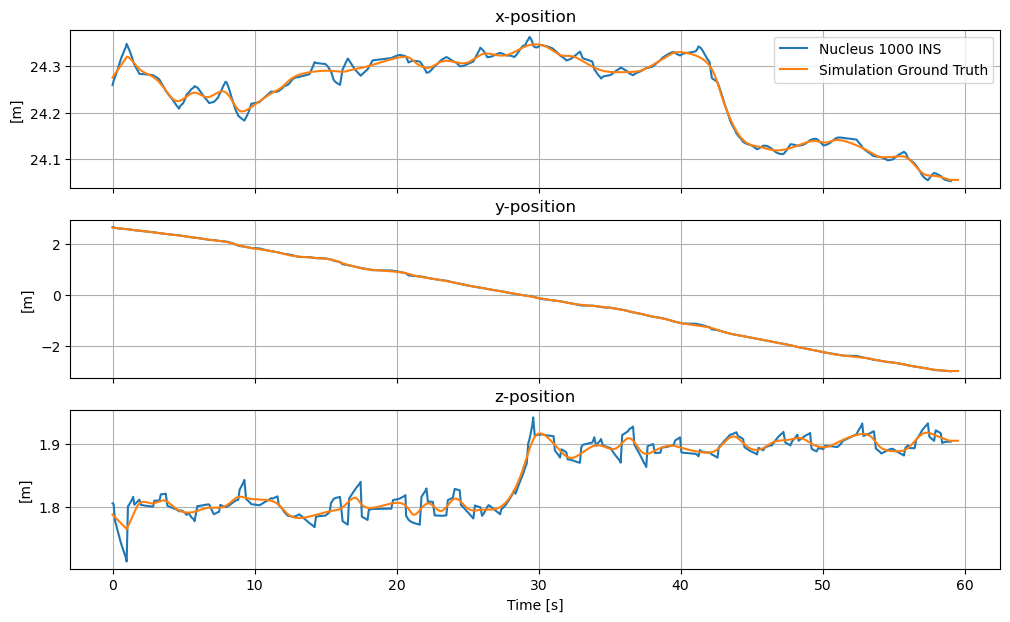

In [127]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(ins_data.t, ins_data.x, label="Nucleus 1000 INS")
axes[0].plot(sim_gt["t"].values, sim_gt["pose.pose.position.x"].values, label="Simulation Ground Truth")
axes[0].set_title("x-position")
axes[0].set_ylabel("[m]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ins_data.t, ins_data.y, label="Nucleus 1000 INS")
axes[1].plot(sim_gt["t"].values, sim_gt["pose.pose.position.y"].values, label="Simulation Ground Truth")
axes[1].set_title("y-position")
axes[1].set_ylabel("[m]")
# axes[1].legend()
axes[1].grid(True)

axes[2].plot(ins_data.t, ins_data.z, label="Nucleus 1000 INS")
axes[2].plot(sim_gt["t"].values, sim_gt["pose.pose.position.z"].values, label="Simulation Ground Truth")
axes[2].set_title("z-position")
axes[2].set_ylabel("[m]")
axes[2].set_xlabel("Time [s]")
# axes[2].legend()
axes[2].grid(True)

comp_x = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.position.x"].values,
                        ins_data.t, ins_data.x)

comp_y = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.position.y"].values,
                        ins_data.t, ins_data.y)

comp_z = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.position.z"].values,
                        ins_data.t, ins_data.z)

print(comp_x)
print(comp_y)
print(comp_z)

# Velocity comparison
Diskuter hvor god banen som simuleres er i forhold til ground trurth

# Velocity comparison using Nucleus frame directly

{'rmse': 0.019917196831634548, 'corr': 0.7153061467679709, 'mean1': -0.0001426446769782208, 'mean2': 0.001651662044866293, 'mean_error': -0.001794306721844514, 'var_signal1': 0.0003173798181994447, 'var_signal2': 0.0007951868581415625, 'var_difference': -0.0004778070399421178, 'var_ratio_s1_over_s2': 0.3991260858374792, 'cv_signal1': 124.89184564584774, 'cv_signal2': 17.073140259155473, 'kurtosis_signal1': 4.447297506789756, 'kurtosis_signal2': -0.03804070696610795, 'kurtosis_difference': 4.485338213755863}
{'rmse': 0.03321138900789391, 'corr': 0.4180105411835468, 'mean1': -0.0951245083668791, 'mean2': -0.09697328570727348, 'mean_error': 0.001848777340394365, 'var_signal1': 0.001140638710587681, 'var_signal2': 0.0007150757280295185, 'var_difference': 0.0004255629825581624, 'var_ratio_s1_over_s2': 1.59512995040519, 'cv_signal1': 0.3550435505542312, 'cv_signal2': 0.2757553249390321, 'kurtosis_signal1': 1.4048339815271396, 'kurtosis_signal2': 0.8323542082289217, 'kurtosis_difference': 0.5

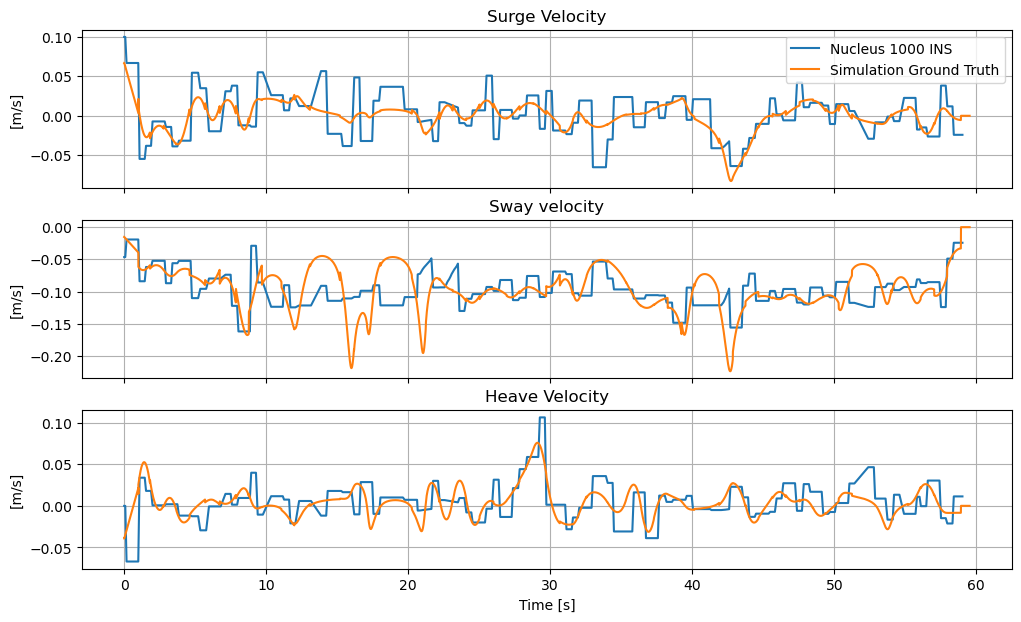

In [128]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

nucleus_ins = ins_data.df_ins

axes[0].plot(nucleus_ins["t"].values, nucleus_ins["velocityNucleus.z"].values, label="Nucleus 1000 INS")
axes[0].plot(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.x"].values, label="Simulation Ground Truth")
axes[0].set_title("Surge Velocity")
axes[0].set_ylabel("[m/s]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.x"].values)
axes[1].plot(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.y"].values)
axes[1].set_title("Sway velocity")
axes[1].set_ylabel("[m/s]")
axes[1].grid(True)


axes[2].plot(nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.y"].values)
axes[2].plot(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.z"].values)
axes[2].set_title("Heave Velocity")
axes[2].set_ylabel("[m/s]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True)

comp_surge = compare_signals(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.x"].values,
                        nucleus_ins["t"].values, nucleus_ins["velocityNucleus.z"].values)

comp_sway = compare_signals(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.y"].values,
                        nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.x"].values)

comp_heave = compare_signals(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.z"].values,
                        nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.y"].values)

print(comp_surge)
print(comp_sway)
print(comp_heave)

# Angular velocity comparison

{'rmse': 0.029150862615972356, 'corr': 0.21471570683343535, 'mean1': -0.00021645998366813936, 'mean2': 0.0009427734601847789, 'mean_error': -0.0011592334438529184, 'var_signal1': 0.00037838001814325447, 'var_signal2': 0.0006903821348595492, 'var_difference': -0.00031200211671629475, 'var_ratio_s1_over_s2': 0.5480733046781864, 'cv_signal1': 89.86415097431627, 'cv_signal2': 27.870029215610924, 'kurtosis_signal1': 4.006824482063209, 'kurtosis_signal2': 11.385322174761445, 'kurtosis_difference': -7.378497692698236}
{'rmse': 0.10342082948178662, 'corr': 0.08510919472402301, 'mean1': -0.09540877959762929, 'mean2': 0.0006231208133672164, 'mean_error': -0.09603190041099652, 'var_signal1': 0.0011014530022009992, 'var_signal2': 0.0005000972570933174, 'var_difference': 0.0006013557451076819, 'var_ratio_s1_over_s2': 2.2024775912647523, 'cv_signal1': 0.34785211221728124, 'cv_signal2': 35.88847286793271, 'kurtosis_signal1': 1.1888012041744194, 'kurtosis_signal2': 9.387939927127848, 'kurtosis_differe

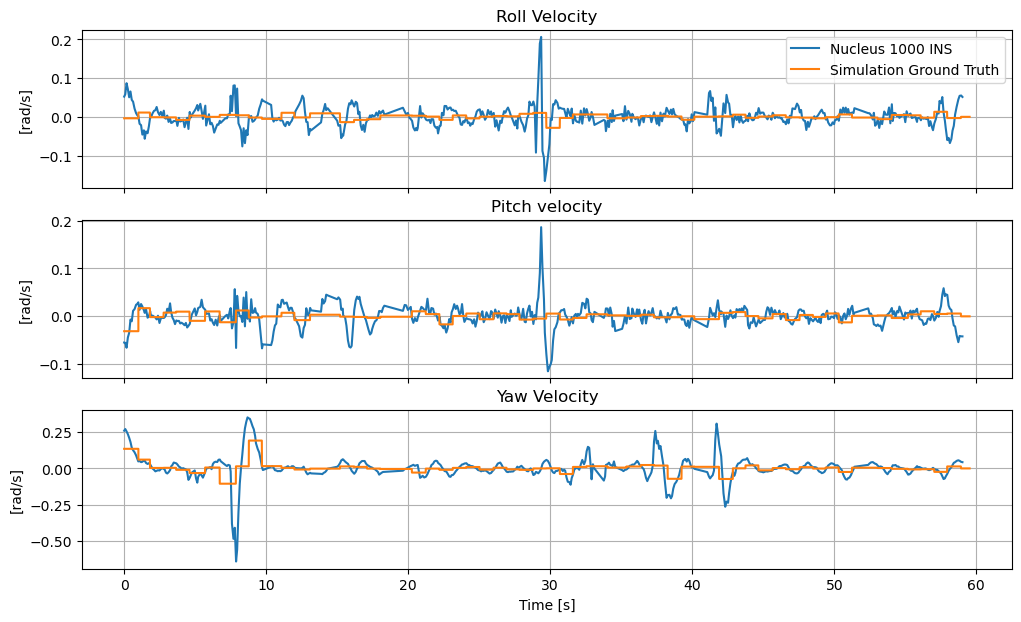

In [129]:
rpy_vel = np.column_stack((np.deg2rad(nucleus_ins["turnRate.x"].values), np.deg2rad(nucleus_ins["turnRate.z"].values), np.deg2rad(-nucleus_ins["turnRate.y"].values)))


fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(ins_data.t, rpy_vel[:,0], label="Nucleus 1000 INS")
axes[0].plot(sim_gt["t"].values, sim_gt["twist.twist.angular.x"].values, label="Simulation Ground Truth")
axes[0].set_title("Roll Velocity")
axes[0].set_ylabel("[rad/s]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ins_data.t, rpy_vel[:,1])
axes[1].plot(sim_gt["t"].values, sim_gt["twist.twist.angular.y"].values)
axes[1].set_title("Pitch velocity")
axes[1].set_ylabel("[rad/s]")
axes[1].grid(True)

axes[2].plot(ins_data.t, rpy_vel[:,2])
axes[2].plot(sim_gt["t"].values, sim_gt["twist.twist.angular.z"].values)
axes[2].set_title("Yaw Velocity")
axes[2].set_ylabel("[rad/s]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True)

comp_roll = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.x"].values,
                        ins_data.t, rpy_vel[:,0])

comp_pitch = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.y"].values,
                        ins_data.t, rpy_vel[:,1])

comp_yaw = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.z"].values,
                        ins_data.t, rpy_vel[:,2])

print(comp_roll)
print(comp_pitch)
print(comp_yaw)

# Beams

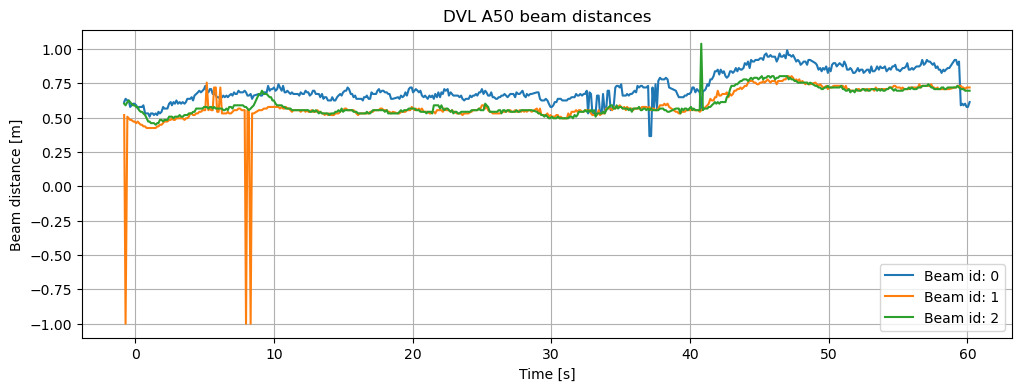

In [130]:
plt.figure(figsize=(12, 4))

# --- DVL-A50 ---
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.0.distance"].values, label="Beam id: 0")
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.1.distance"].values, label="Beam id: 1")
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.2.distance"].values, label="Beam id: 2")

plt.title("DVL A50 beam distances")
plt.xlabel("Time [s]")
plt.ylabel("Beam distance [m]")

# plt.ylim((-0.05, 0.25))

plt.legend()
plt.grid()

# INS Linear velocity 
# TODO: Fjern konstant g!

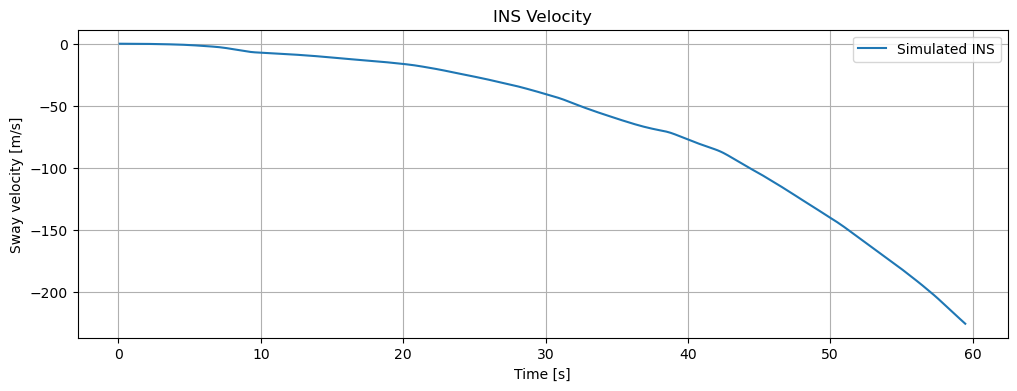

In [131]:
plt.figure(figsize=(12, 4))

plt.plot(sim_ins["t"].values, -sim_ins["pose.north"].values, label="Simulated INS")

# plt.plot(nucleus_ins["t"].values, nucleus_ins["velocityNed.x"].values, label="Nucleus 1000 INS")

# plt.plot(sim_gt["t"].values, -sim_gt["twist.twist.linear.y"].values-0.1, label="Simulation Ground Truth")

plt.title("INS Velocity")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")

# plt.ylim((-0.05, 0.25))

plt.legend()
plt.grid()

# Net Distance

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


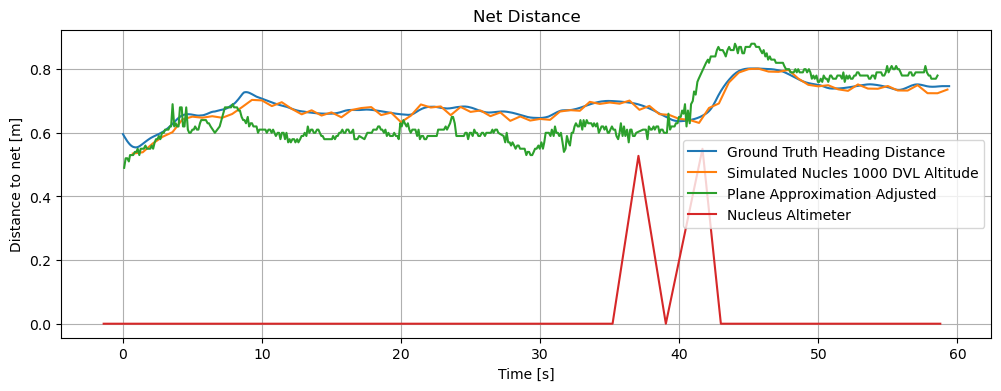

In [132]:
heading_dist_gt = get_profiler_data(SIM_BAG_PATH, "/heading_distance_ground_truth")
plane_approximation = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/navigation/plane_approximation")
normalize_time(plane_approximation)


# Remove outliers and bias
plane_approx_copy = plane_approximation.copy()
plane_approx_copy["diff"] = plane_approx_copy["NetDistance"].diff()
plane_approx_copy = plane_approx_copy[abs(plane_approx_copy["diff"]) <= 0.1]


dist_dvl_imu = 0.178

plt.figure(figsize=(12, 4))
plt.plot(heading_dist_gt["time"], np.array(heading_dist_gt["ranges"]) + dist_dvl_imu, label="Ground Truth Heading Distance")
plt.plot(sim_dvl["t"].values, sim_dvl["altitude"].values + dist_dvl_imu, label="Simulated Nucles 1000 DVL Altitude")
# plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["altitude"].values, label="DVL-A50 Altitude")

# plt.plot(plane_approximation["t"].values, plane_approximation["NetDistance"].values, label="Plane Approximation")
plt.plot(plane_approx_copy["t"].values, plane_approx_copy["NetDistance"].values, label="Plane Approximation Adjusted")


plt.plot(nucleus_alitmeter["t"].values, nucleus_alitmeter["altimeter_distance"].values, label="Nucleus Altimeter")


plt.title("Net Distance")
plt.xlabel("Time [s]")
plt.ylabel("Distance to net [m]")
plt.legend()
plt.grid()

Liten avvik i starten er mest sannsynlig på grunn av vinkelen på roven. Siden dvl har en vinkel på 4 beams.

# Pressure

In [133]:
# Read csv
real_depth_df = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/depth_temperature")
sim_depth_df = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/pressure")
sim_depth_gt_df = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth")

set_t0(real_depth_df, t0_real)
set_t0(sim_depth_df, t0_sim)
set_t0(sim_depth_gt_df, t0_sim)

RHO = 1031 # [kg/m^3]
g = 9.81

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


{'rmse': 0.010582229919616822, 'corr': 0.977638440783835, 'mean1': 1.8528797191428308, 'mean2': 1.8526315365170312, 'mean_error': 0.00024818262579938844, 'var_signal1': 0.002475512307478472, 'var_signal2': 0.0025242282510262886, 'var_difference': -4.871594354781666e-05, 'var_ratio_s1_over_s2': 0.9807006582990226, 'cv_signal1': 0.02685253659952582, 'cv_signal2': 0.027119099151196212, 'kurtosis_signal1': -1.7816320899079832, 'kurtosis_signal2': -1.8174048017947535, 'kurtosis_difference': 0.035772711886770336}


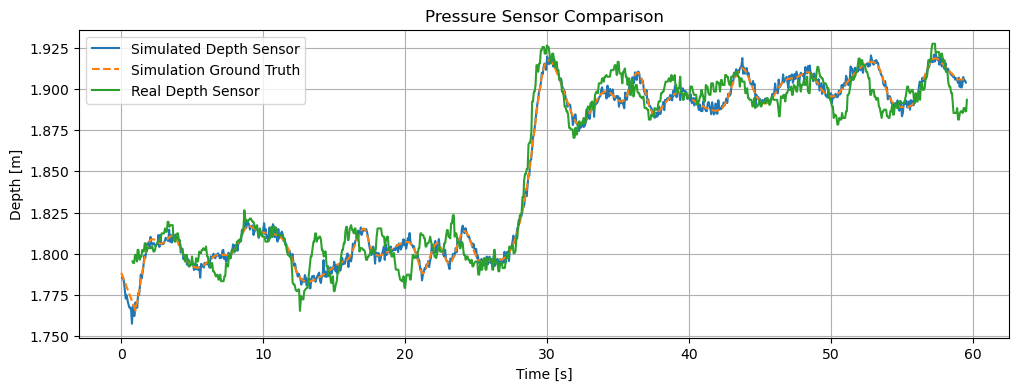

In [134]:
# Remove offset
real_depth_df["depth"] -= real_depth_df["depth"].mean()
real_depth_df["depth"] += sim_gt["pose.pose.position.z"].mean()

# get array of data
depth_real = real_depth_df["depth"].values
depth_sim = (sim_depth_df["fluid_pressure"].values) / (RHO * g)
sim_depth_gt = sim_depth_gt_df["pose.pose.position.z"].values
t_sim = sim_depth_df["t"].values
t_sim_gt = sim_depth_gt_df["t"].values
t_real = real_depth_df["t"].values

lag_sec = get_signal_lag(t_sim_gt, sim_depth_gt,
                        t_real, depth_real)

plt.figure(figsize=(12, 4))
plt.plot(t_sim, depth_sim, label="Simulated Depth Sensor")
plt.plot(t_sim_gt, sim_depth_gt, label="Simulation Ground Truth", ls="--")
plt.plot(t_real - lag_sec, depth_real, label="Real Depth Sensor")

plt.title("Pressure Sensor Comparison")
plt.xlabel("Time [s]")
plt.ylabel("Depth [m]")
plt.legend()
plt.grid()

comp_depth = compare_signals(t_real - lag_sec, depth_real,
                        t_sim, depth_sim)

print(comp_depth)

Comparing gague pressure

In [135]:
# IMU Comparison
print_df_frequency(nucleus_imu)

Avg. frequency: 95.97 Hz


{'rmse': 0.23259588404050743, 'corr': 0.15352752327286145, 'mean1': 0.19854723194212046, 'mean2': 0.024951933035805854, 'mean_error': 0.17359529890631462, 'var_signal1': 0.020275775606078204, 'var_signal2': 0.007500282068740599, 'var_difference': 0.012775493537337606, 'var_ratio_s1_over_s2': 2.7033350773010043, 'cv_signal1': 0.7171746025436857, 'cv_signal2': 3.4708400653163443, 'kurtosis_signal1': 9.436729315906542, 'kurtosis_signal2': 1.1880562296259702, 'kurtosis_difference': 8.248673086280572}
{'rmse': 0.8312413154847409, 'corr': -0.05480083394597294, 'mean1': -0.0704694713172658, 'mean2': 0.7452925320415952, 'mean_error': -0.8157620033588611, 'var_signal1': 0.015973544059255752, 'var_signal2': 0.00828555992411963, 'var_difference': 0.007687984135136123, 'var_ratio_s1_over_s2': 1.9278774404559025, 'cv_signal1': 1.7934927634808782, 'cv_signal2': 0.1221333196921614, 'kurtosis_signal1': 2.042633353709663, 'kurtosis_signal2': 2.463696999393159, 'kurtosis_difference': -0.4210636456834962

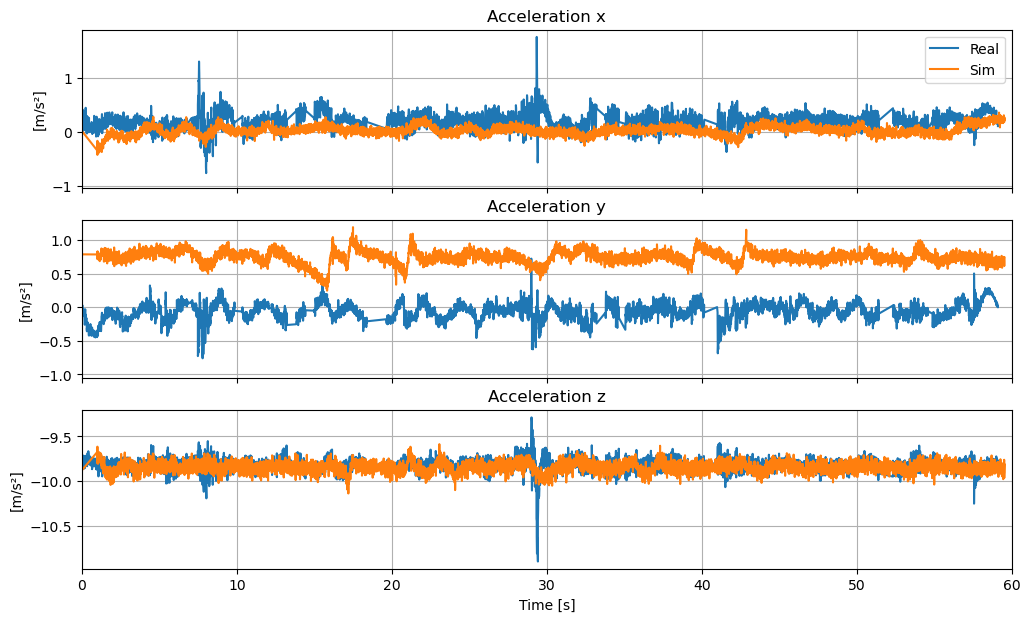

In [136]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(nucleus_imu["t"].values, nucleus_imu["accelerometer.x"].values, label="Real")
axes[0].plot(sim_imu["t"].values, sim_imu["linear_acceleration.x"].values, label="Sim")
axes[0].set_title("Acceleration x")
axes[0].set_ylabel("[m/s²]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(nucleus_imu["t"].values, nucleus_imu["accelerometer.z"].values, label="Real")
axes[1].plot(sim_imu["t"].values, sim_imu["linear_acceleration.y"].values, label="Sim")
axes[1].set_title("Acceleration y")
axes[1].set_ylabel("[m/s²]")
axes[1].grid(True)

axes[2].plot(nucleus_imu["t"].values, -nucleus_imu["accelerometer.y"].values, label="Real")
axes[2].plot(sim_imu["t"].values, sim_imu["linear_acceleration.z"].values, label="Sim")
axes[2].set_title("Acceleration z")
axes[2].set_ylabel("[m/s²]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True)

axes[0].set_xlim((0, 60))


acc_x = compare_signals(nucleus_imu["t"].values, nucleus_imu["accelerometer.x"].values,
                        sim_imu["t"].values, sim_imu["linear_acceleration.x"].values)

acc_y = compare_signals(nucleus_imu["t"].values, nucleus_imu["accelerometer.z"].values,
                        sim_imu["t"].values, sim_imu["linear_acceleration.y"].values)

acc_z = compare_signals(nucleus_imu["t"].values, -nucleus_imu["accelerometer.y"].values,
                        sim_imu["t"].values, sim_imu["linear_acceleration.z"].values)

print(acc_x)
print(acc_y)
print(acc_z)

Simulerer ikke dorpouts

(0.0, 60.0)

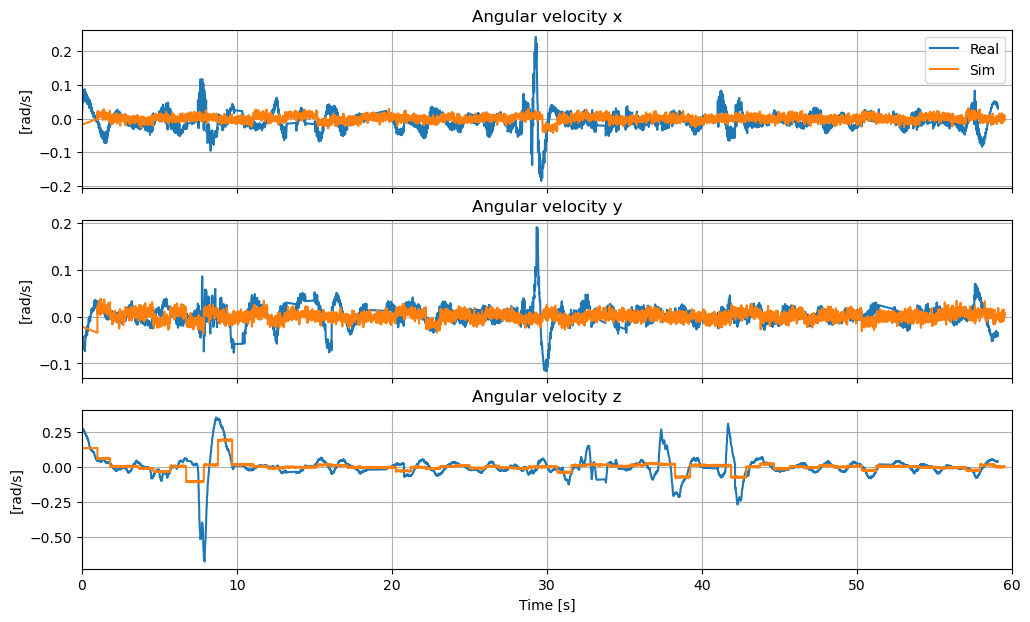

In [137]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(nucleus_imu["t"].values, nucleus_imu["gyroscope.x"].values, label="Real")
axes[0].plot(sim_imu["t"].values, sim_imu["angular_velocity.x"].values, label="Sim")
axes[0].set_title("Angular velocity x")
axes[0].set_ylabel("[rad/s]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(nucleus_imu["t"].values, nucleus_imu["gyroscope.z"].values, label="Real")
axes[1].plot(sim_imu["t"].values, sim_imu["angular_velocity.y"].values, label="Sim")
axes[1].set_title("Angular velocity y")
axes[1].set_ylabel("[rad/s]")
axes[1].grid(True)

axes[2].plot(nucleus_imu["t"].values, -nucleus_imu["gyroscope.y"].values, label="Real")
axes[2].plot(sim_imu["t"].values, sim_imu["angular_velocity.z"].values, label="Sim")
axes[2].set_title("Angular velocity z")
axes[2].set_ylabel("[rad/s]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True)

axes[0].set_xlim((0, 60))

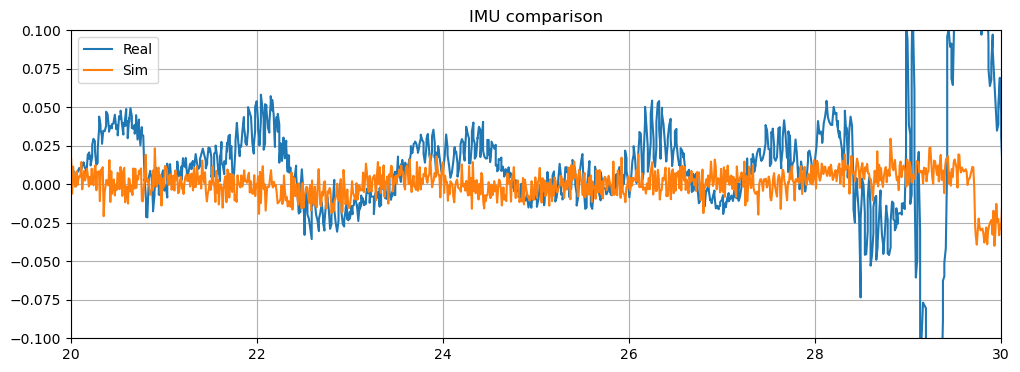

In [138]:
# IMU Comparison
plt.figure(figsize=(12, 4))



plt.plot(nucleus_imu["t"].values, -nucleus_imu["gyroscope.x"].values, label="Real")
plt.plot(sim_imu["t"].values, sim_imu["angular_velocity.x"].values, label="Sim")

plt.legend()


plt.title("IMU comparison")

plt.xlim((20, 30))
plt.ylim((-0.1, 0.1))

plt.legend()
plt.grid()